In [ ]:
import pandas as pd
import numpy as np
import os
import sqlalchemy
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt


server = "SERVER_NAME" 
database = "Movies"

connection_string = (
   "YOUR_CONNECTION_STRING"
)

engine = create_engine(connection_string)

In [10]:
df_sentiment = pd.read_sql("SELECT * FROM [Movies].[dbo].[Sentiment Forecast]", engine)
df_topic = pd.read_sql("SELECT * FROM [Movies].[dbo].[Topic Forecast]",engine)
df_movie = pd.read_sql("SELECT * FROM [Movies].[dbo].[Movie]",engine)
df_sentiment = pd.merge(df_sentiment, df_movie, on=["ID Movie"])
df_topic = pd.merge(df_topic, df_movie, on=["ID Movie"])

In [11]:
df_sentiment["Movie"].value_counts()

Movie
Avatar               16550
Frankestein           9560
Wuthering Heights     9254
Name: count, dtype: int64

## Sentiment Analysis

In [64]:
df_sentiment[df_sentiment["Movie"]=="Avatar"]["Sentiment Forecast"].value_counts()

Sentiment Forecast
negative    6404
neutral     5774
positive    4372
Name: count, dtype: int64

In [68]:
for movie in df_sentiment["Movie"].unique():
    sentiment_counts = (
        df_sentiment[df_sentiment["Movie"] == movie]["Sentiment Forecast"]
        .value_counts()
    )
    print(f"\n🎬 Movie: {movie}")
    print("-" * 30)

    for sentiment, count in sentiment_counts.items():
        print(f"{sentiment:<10}: {count}")


🎬 Movie: Avatar
------------------------------
negative  : 6404
neutral   : 5774
positive  : 4372

🎬 Movie: Frankestein
------------------------------
positive  : 3845
negative  : 2914
neutral   : 2801

🎬 Movie: Wuthering Heights
------------------------------
negative  : 4508
neutral   : 2651
positive  : 2095


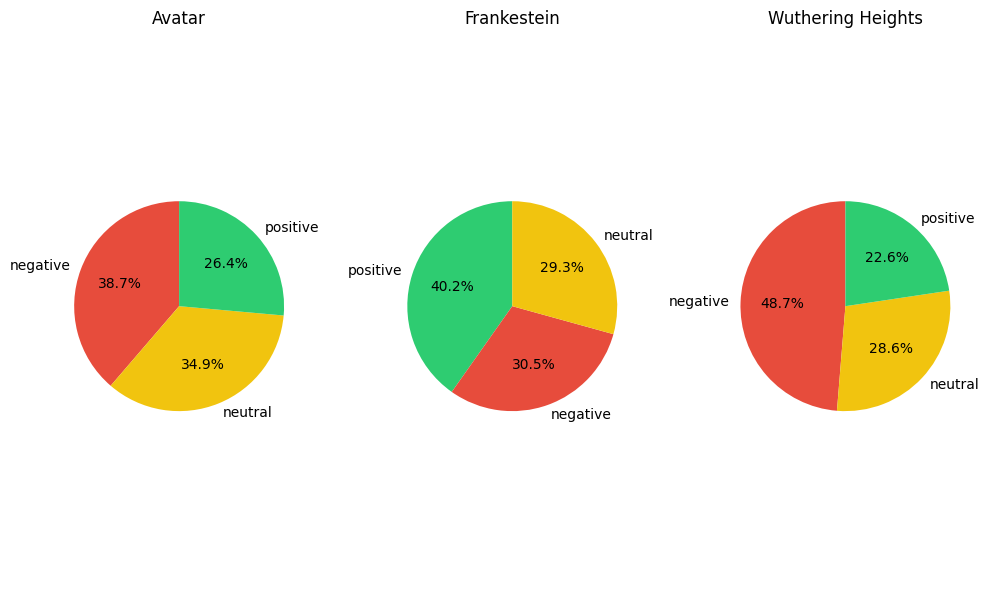

In [ ]:
color_map = {
    "positive": "#2ecc71",
    "neutral": "#f1c40f",
    "negative": "#e74c3c"
}

movies = df_sentiment["Movie"].unique()
fig, axes = plt.subplots(1, 3, figsize=(10, 6))
axes = axes.flatten()

for ax, movie in zip(axes, movies):
    count_sentiment = (
        df_sentiment[df_sentiment["Movie"] == movie]["Sentiment Forecast"]
        .value_counts()
    )

    labels = count_sentiment.index
    sizes = count_sentiment.values
    colors = [color_map[label] for label in labels]


    ax.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        colors = colors,
        startangle=90
    )
    ax.set_title(movie)
    ax.axis('equal')

# Nasconde eventuali subplot vuoti
for ax in axes[len(movies):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Primary Topic

In [51]:
df_primary_topics = df_topic[["ID Movie","Movie","ID Comment","Primary Topic","Primary Score"]].drop_duplicates()
df_primary_topics = pd.merge(df_sentiment[["ID Movie","ID Comment","Sentiment Forecast"]], df_primary_topics, on=["ID Movie","ID Comment"])

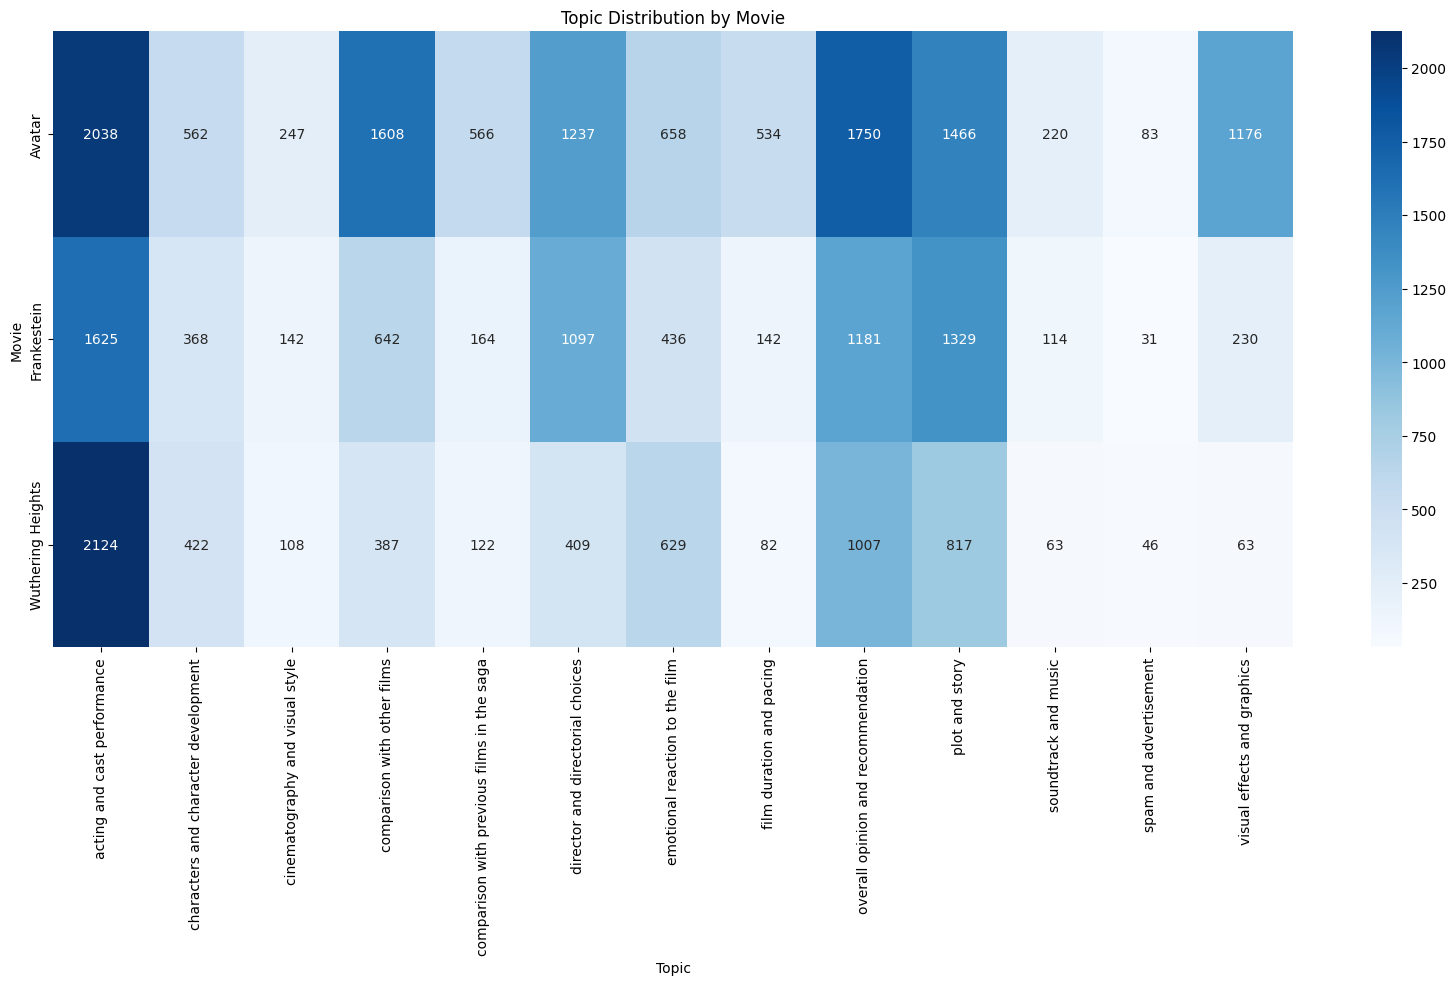

In [ ]:
heatmap_data = pd.crosstab(
    df_primary_topics["Movie"],
    df_primary_topics["Primary Topic"]
)

plt.figure(figsize=(20,8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Topic Distribution by Movie")
plt.xlabel("Topic")
plt.ylabel("Movie")
plt.show()

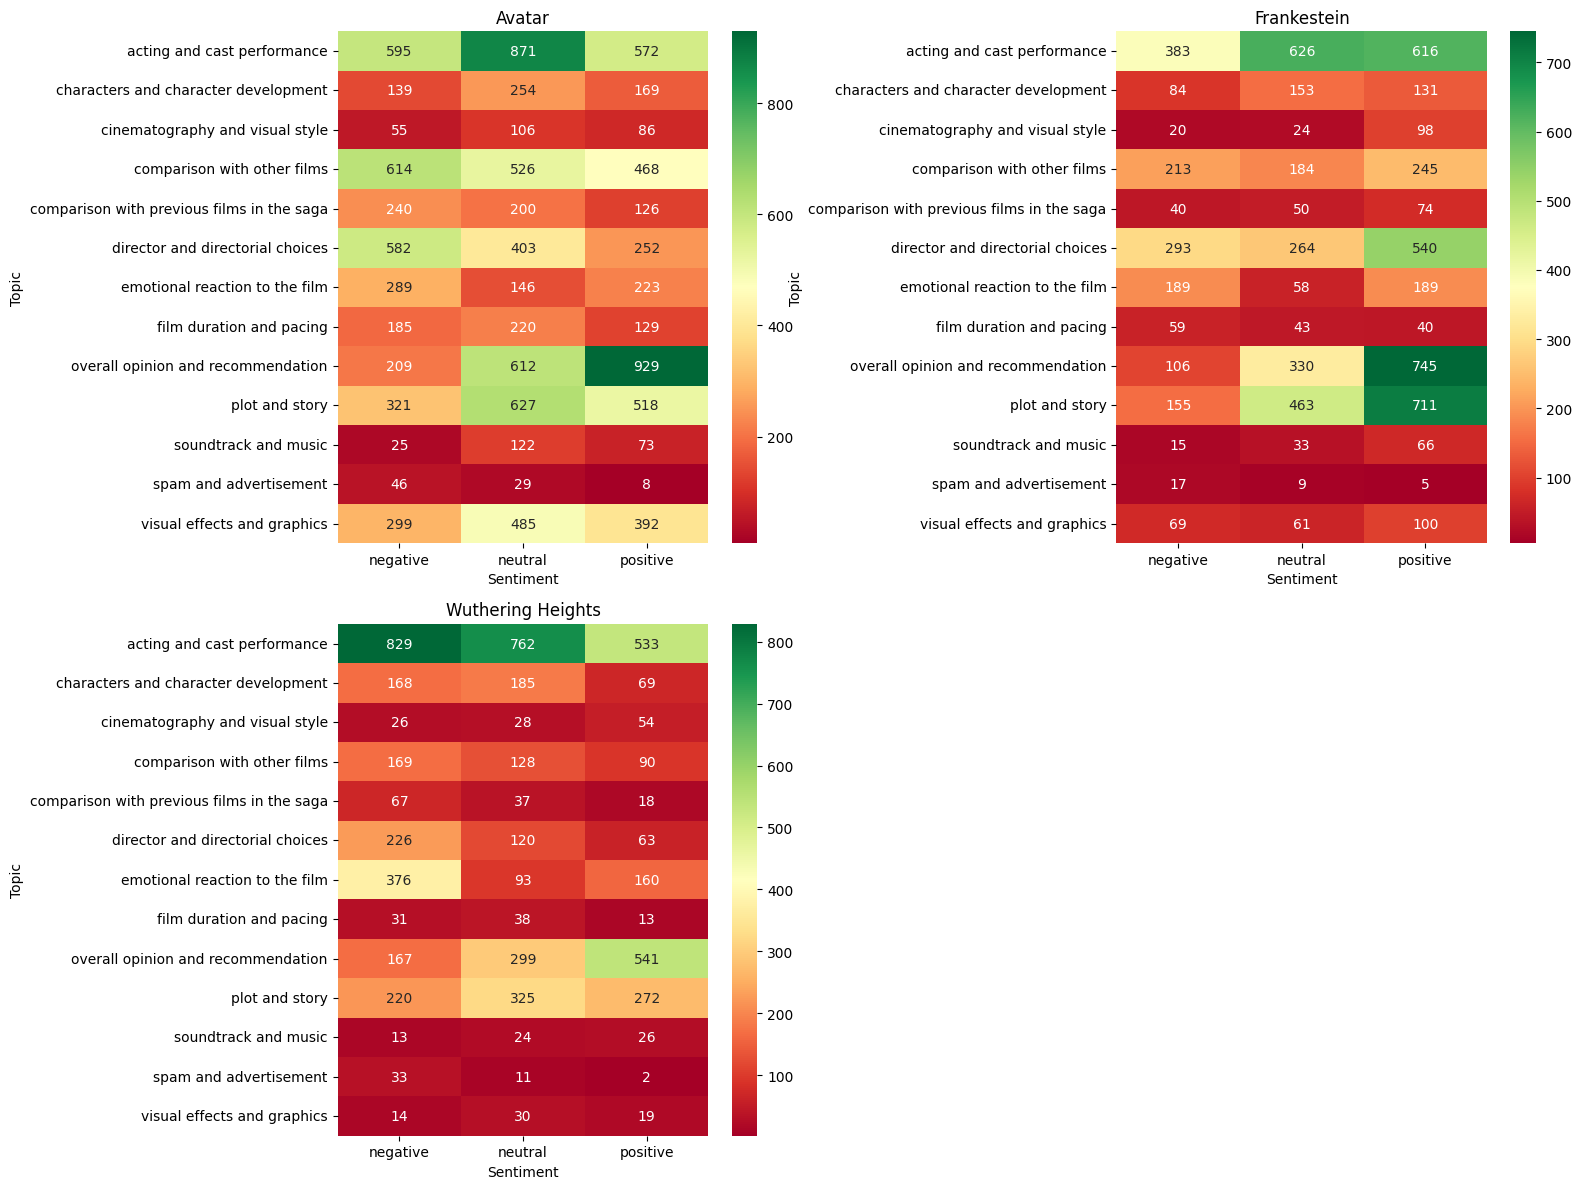

In [48]:
movies = df_primary_topics["Movie"].unique()

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 12)
)
axes = axes.flatten()

for ax, movie in zip(axes, movies):
    subset = df_primary_topics[df_primary_topics["Movie"] == movie]

    heatmap_data = pd.crosstab(
        subset["Primary Topic"],
        subset["Sentiment Forecast"]
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        cmap="RdYlGn",
        fmt="d",
        ax=ax
    )

    ax.set_title(movie)
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Topic")

# Hide unused subplot
for ax in axes[len(movies):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

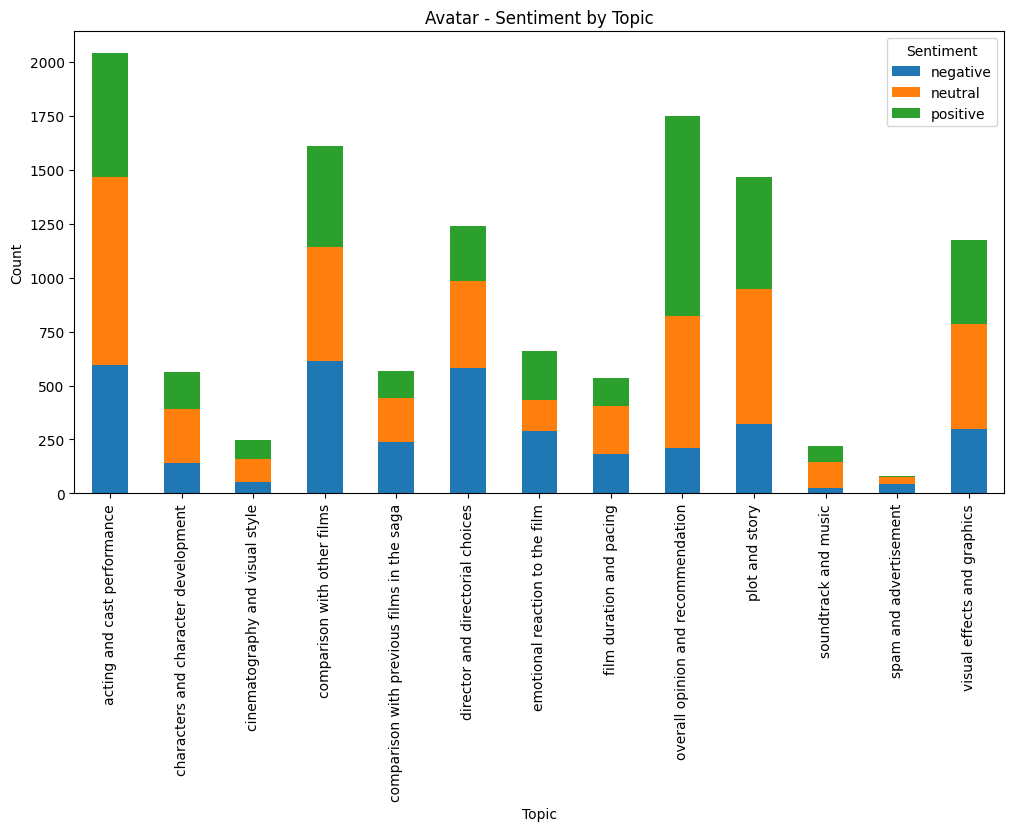

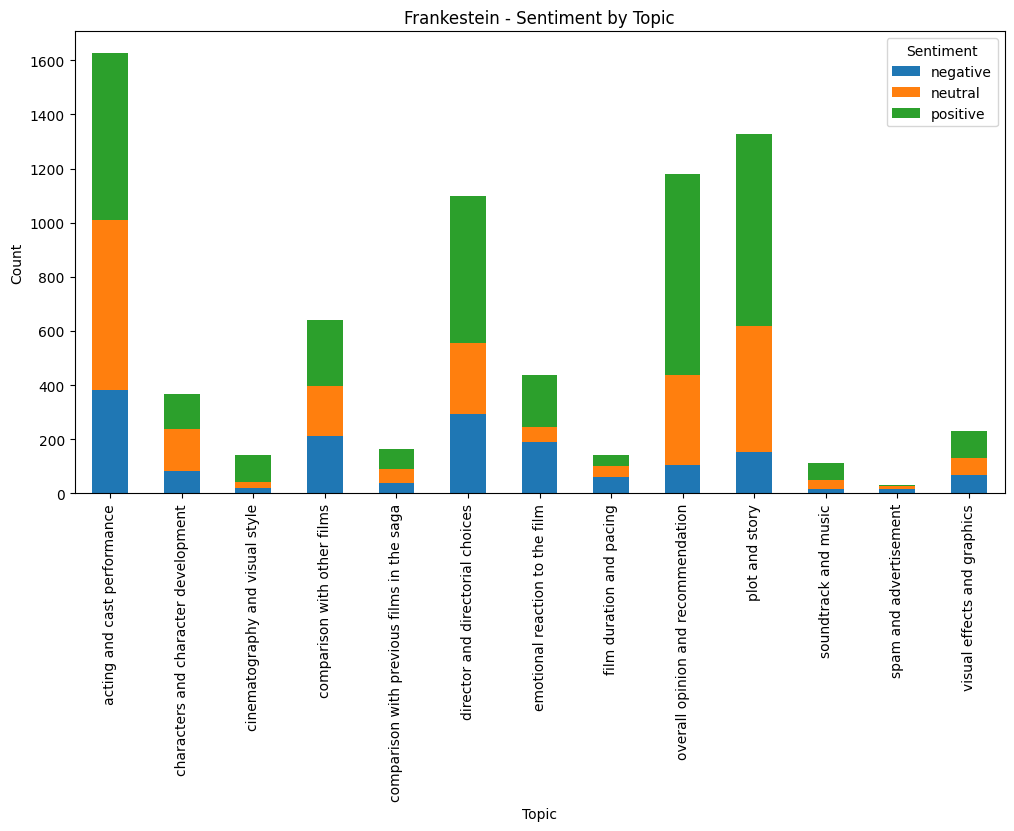

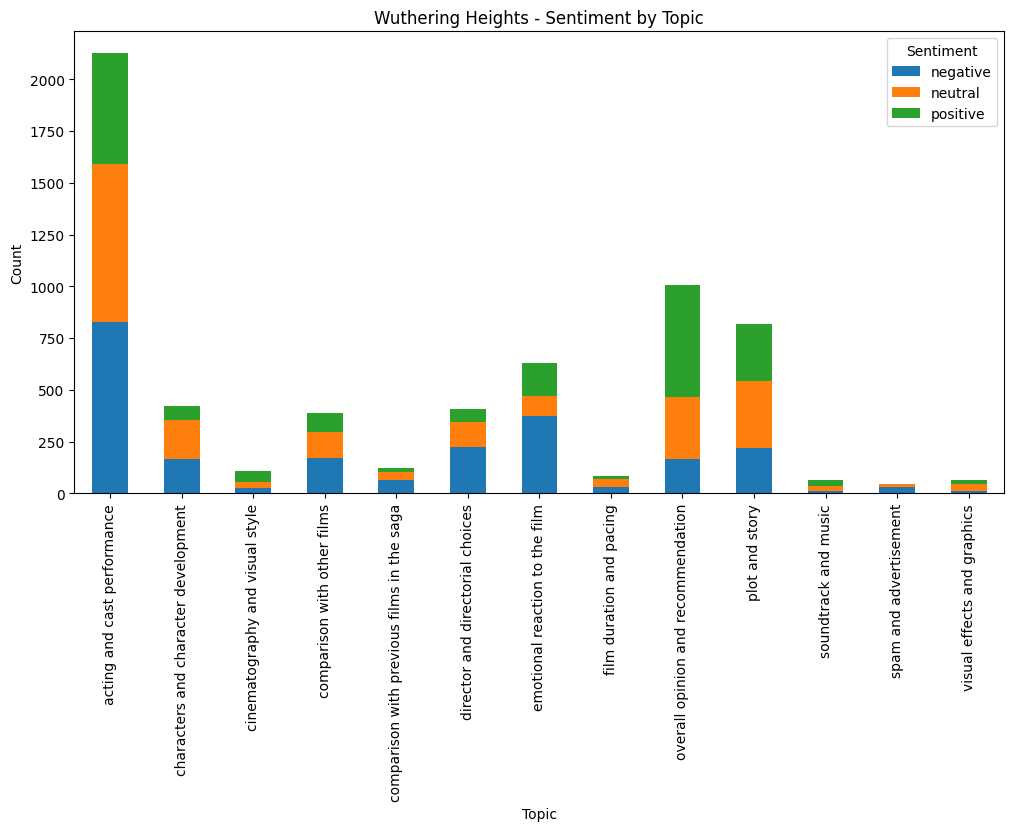

In [50]:
sentiment_counts = (
    df_primary_topics
    .groupby(["Movie", "Primary Topic", "Sentiment Forecast"])
    .size()
    .unstack(fill_value=0)
)

for movie in df_primary_topics["Movie"].unique():
    sentiment_counts.loc[movie].plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6)
    )

    plt.title(f"{movie} - Sentiment by Topic")
    plt.xlabel("Topic")
    plt.ylabel("Count")
    plt.legend(title="Sentiment")
    plt.show()

## All Topics

In [56]:
df_topic_filtered = df_topic[df_topic["Topic Score"]>= 0.7] # just take topics with high confidence
df_topic_filtered = pd.merge(df_sentiment[["ID Movie","ID Comment","Sentiment Forecast"]], df_topic_filtered, on=["ID Movie","ID Comment"])

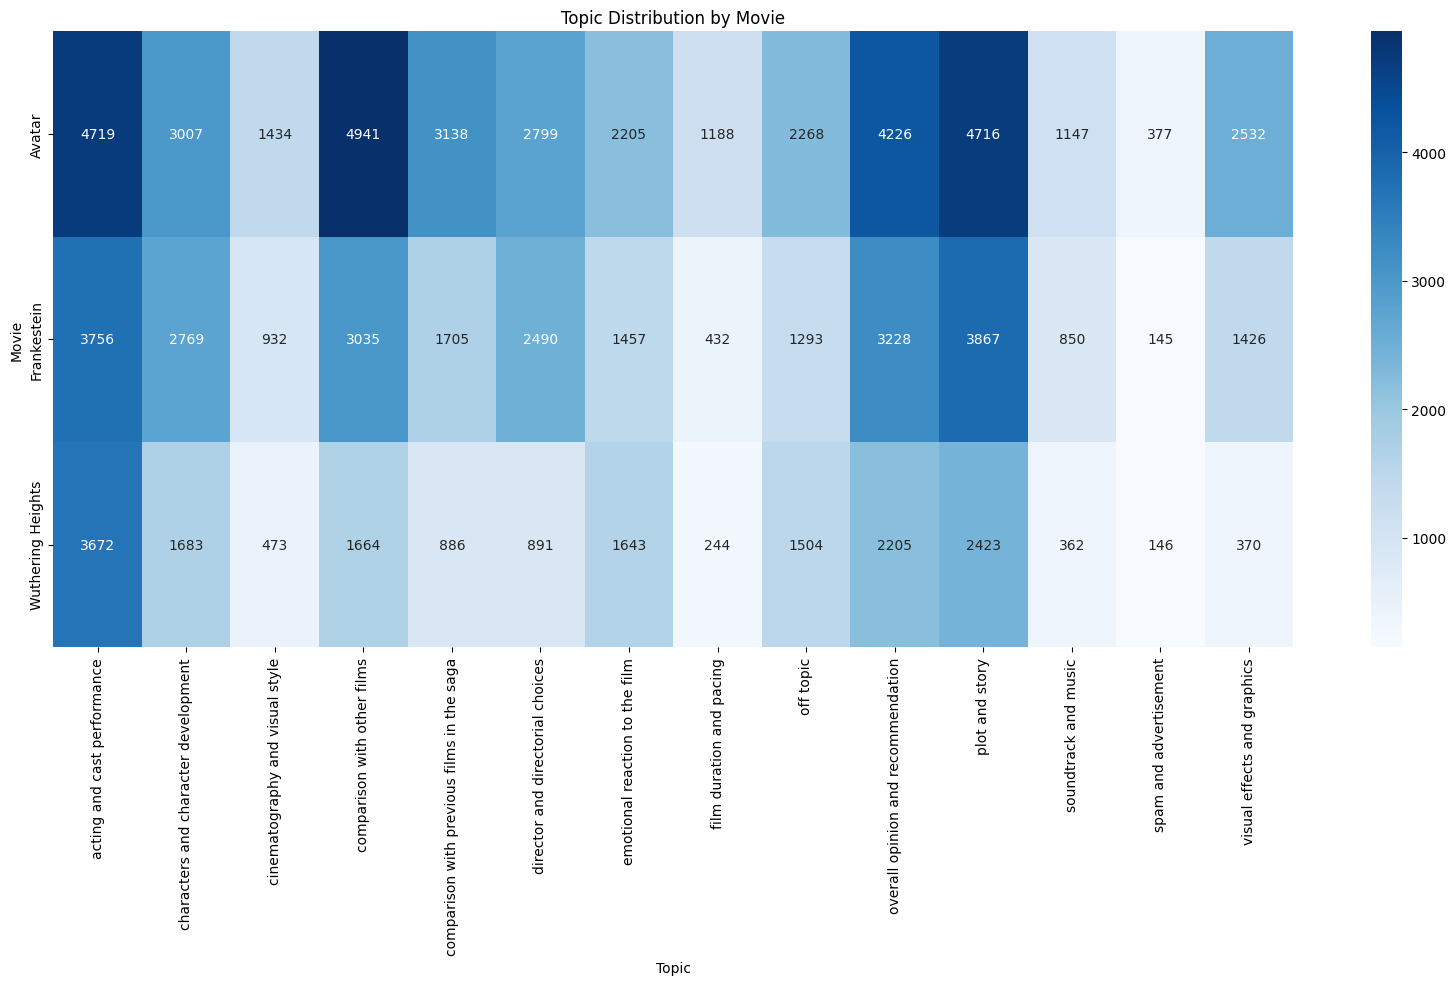

In [57]:
heatmap_data = pd.crosstab(
    df_topic_filtered["Movie"],
    df_topic_filtered["Topic"]
)

plt.figure(figsize=(20,8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Topic Distribution by Movie")
plt.xlabel("Topic")
plt.ylabel("Movie")
plt.show()

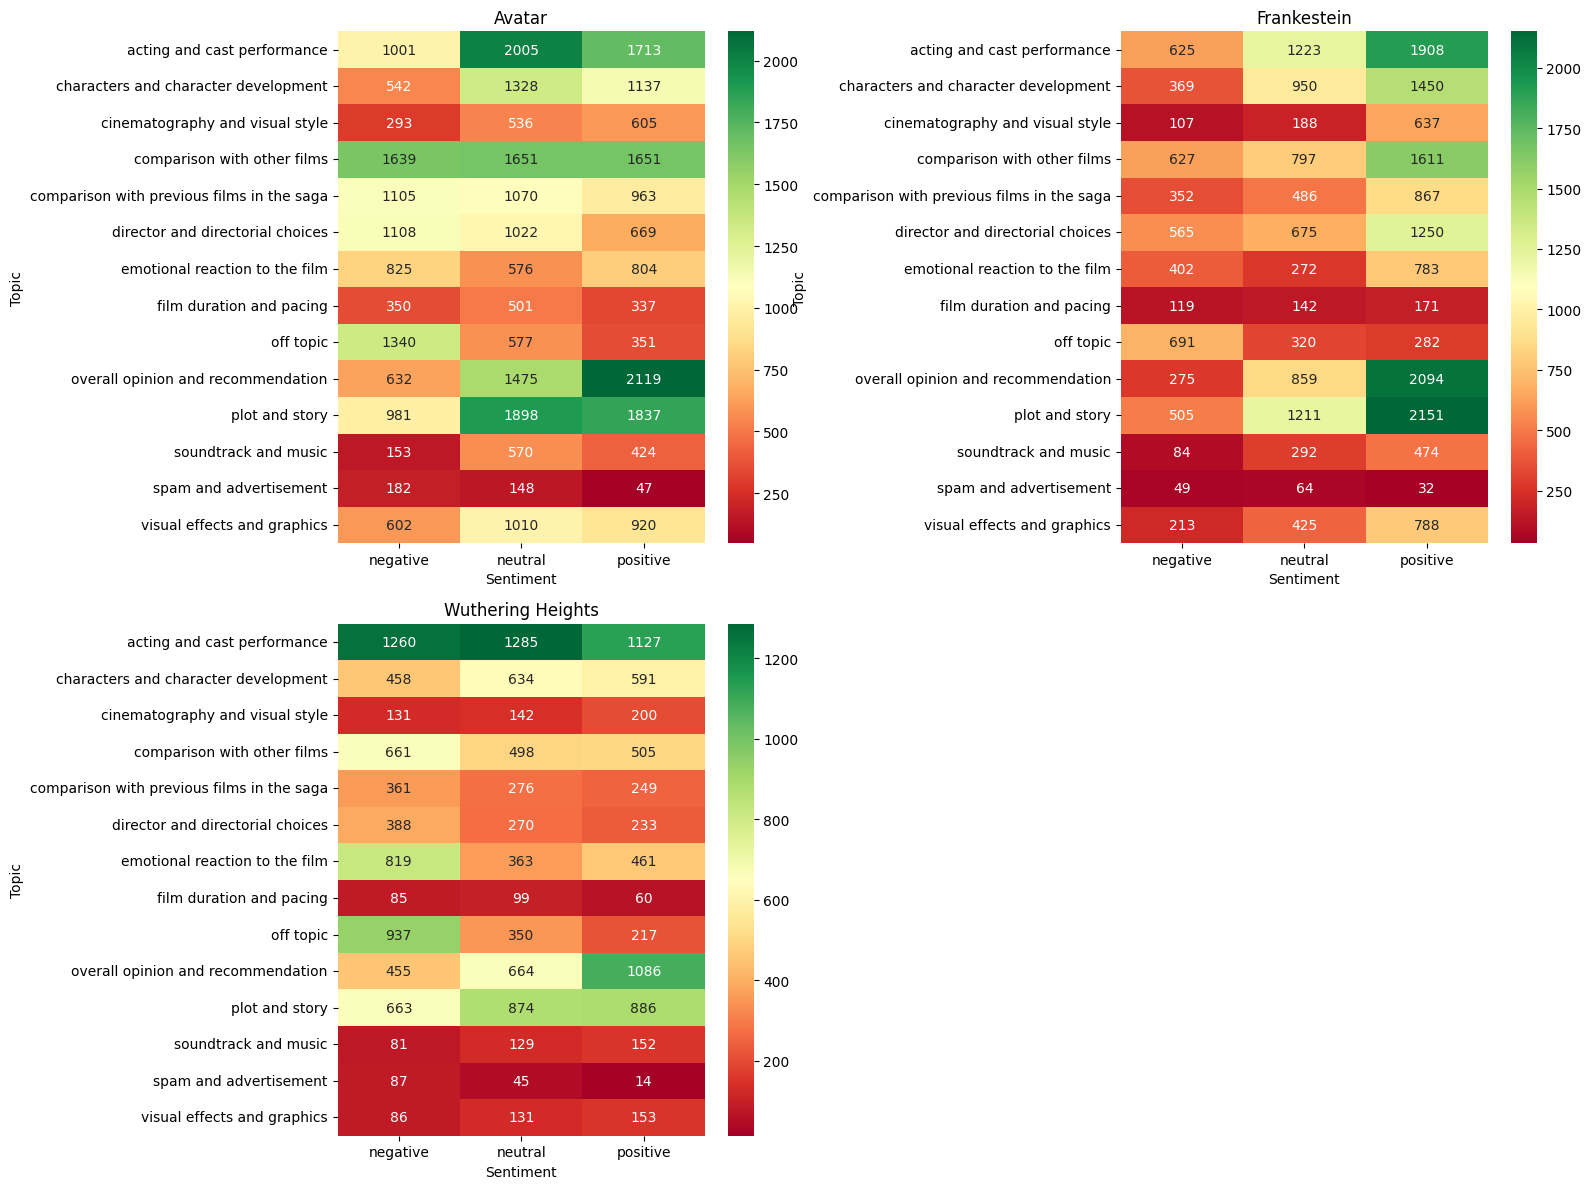

In [60]:
movies = df_topic_filtered["Movie"].unique()

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 12)
)
axes = axes.flatten()

for ax, movie in zip(axes, movies):
    subset = df_topic_filtered[df_topic_filtered["Movie"] == movie]

    heatmap_data = pd.crosstab(
        subset["Topic"],
        subset["Sentiment Forecast"]
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        cmap="RdYlGn",
        fmt="d",
        ax=ax
    )

    ax.set_title(movie)
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Topic")

# Hide unused subplot
for ax in axes[len(movies):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

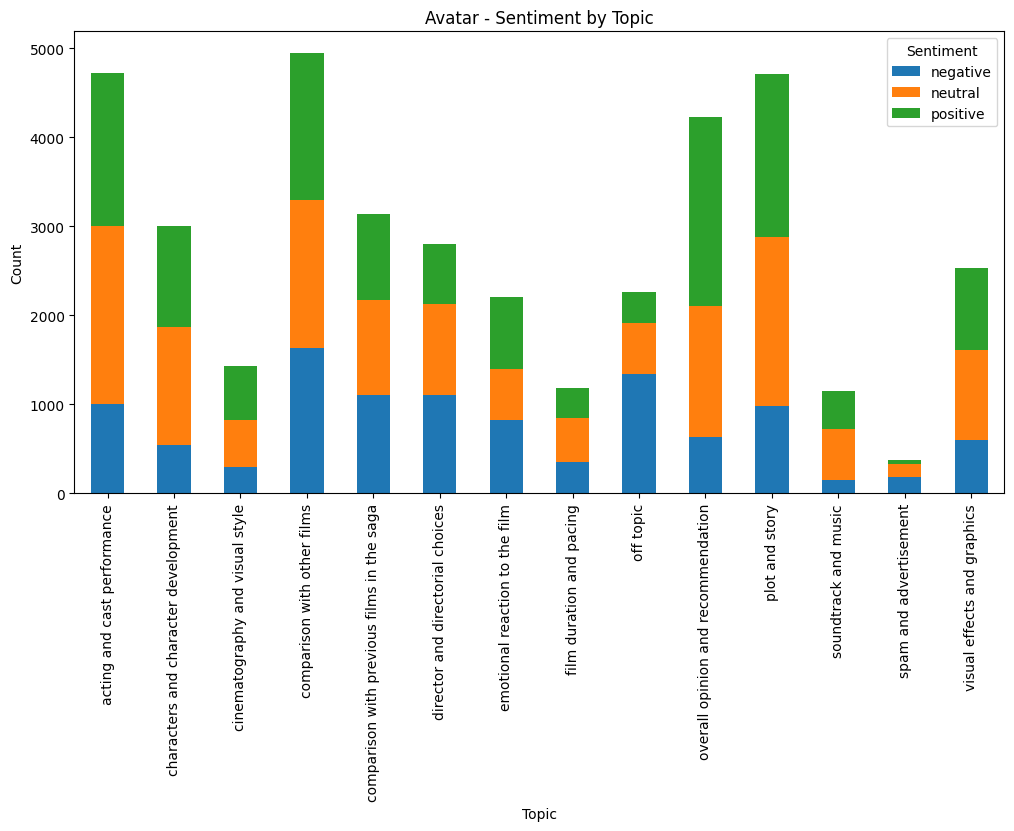

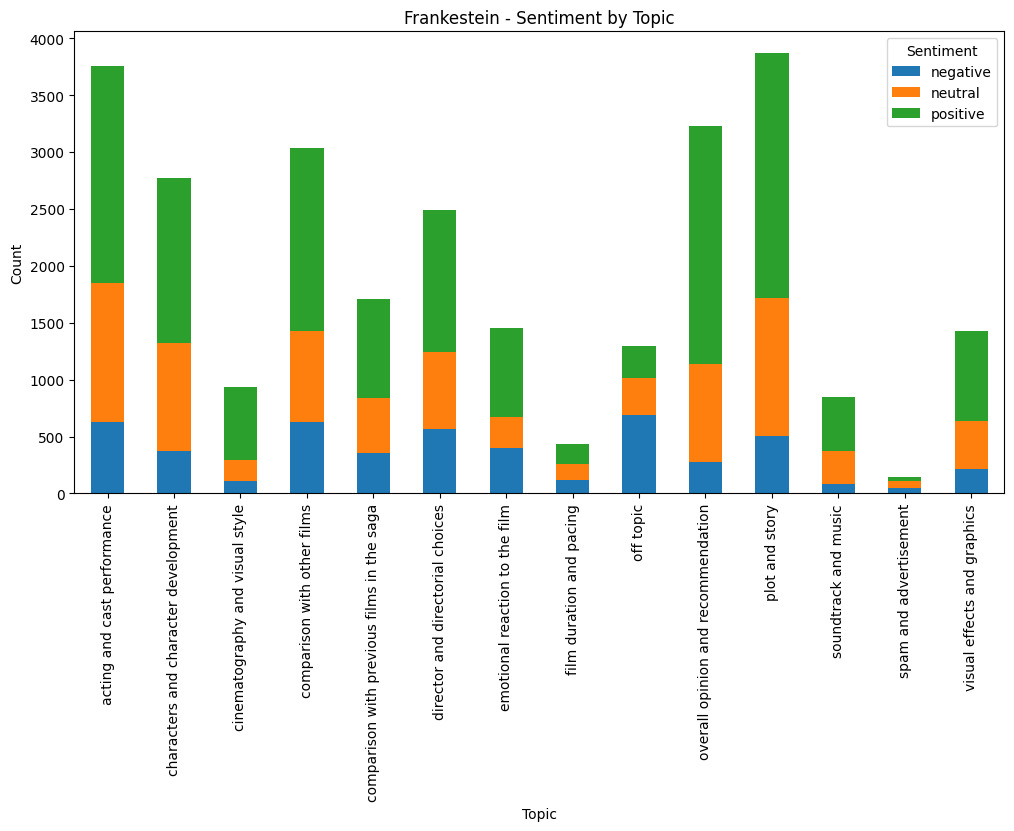

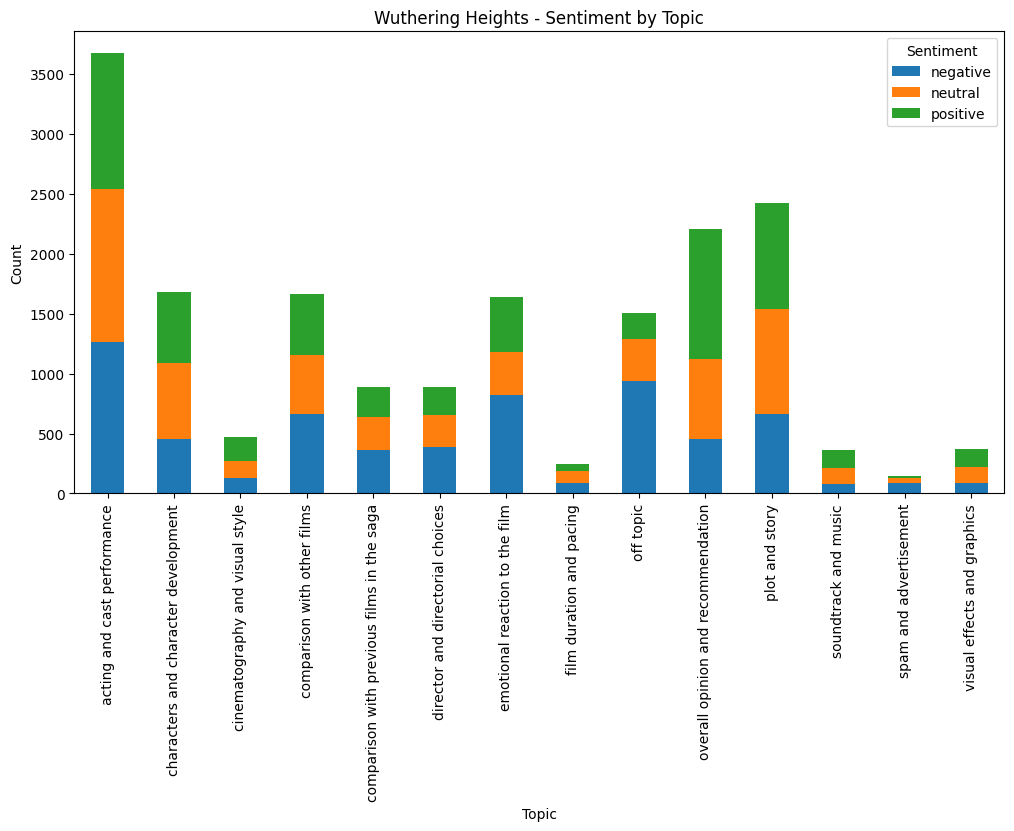

In [61]:
sentiment_counts = (
    df_topic_filtered
    .groupby(["Movie", "Topic", "Sentiment Forecast"])
    .size()
    .unstack(fill_value=0)
)

for movie in df_topic_filtered["Movie"].unique():
    sentiment_counts.loc[movie].plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6)
    )

    plt.title(f"{movie} - Sentiment by Topic")
    plt.xlabel("Topic")
    plt.ylabel("Count")
    plt.legend(title="Sentiment")
    plt.show()